In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mexwell/telecom-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


## 1. Importing Dependencies

In [48]:
# ================================
# IMPORTING REQUIRED LIBRARIES
# ================================

# Numerical computations and array operations
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Used to convert categorical labels into numerical format
from sklearn.preprocessing import LabelEncoder

# Utilities for splitting dataset and performing cross-validation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# SMOTE is used to handle imbalanced datasets
# by generating synthetic samples for minority classes
from imblearn.over_sampling import SMOTE

# Machine Learning Algorithms

# Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

# Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Extreme Gradient Boosting Random Forest classifier
from xgboost import XGBClassifier

# Evaluation metrics used to measure model performance
from sklearn.metrics import (
    accuracy_score,      # Calculates accuracy of the model
    confusion_matrix,    # Displays prediction confusion matrix
    classification_report # Generates precision, recall, f1-score
)

# Used to save and load trained machine learning models
import pickle

print("All the dependencies are imported!!!1")

All the dependencies are imported!!!1


## 2. Data Importing and Understanding

In [4]:
# ==========================================
# LOADING THE DATASET USING PANDAS
# ==========================================

# Reading the CSV file from the specified path
# and storing it inside the variable 'dataset'
dataset = pd.read_csv(
    "/kaggle/input/datasets/mexwell/telecom-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# Displaying the first 5 rows of the dataset
# to understand the structure and features
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# ==========================================
# DISPLAYING DATASET INFORMATION
# ==========================================

# info() provides a summary of the dataset including:
# - Total number of rows and columns
# - Column names
# - Data types of each column
# - Number of non-null values
# - Memory usage

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# ==========================================
# CHECKING FOR MISSING VALUES
# ==========================================

# isnull() identifies missing/null values in the dataset
# sum() counts the total number of missing values in each column

dataset.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 3. Data Preprocessing

## 3.1 Removing Uneccesary columns

In [7]:
# ==========================================
# DROPPING UNNECESSARY COLUMNS
# ==========================================

# Removing the 'customerID' column from the dataset
# because it is only a unique identifier and
# does not contribute to model prediction

dataset = dataset.drop(columns=['customerID'], axis=1)

print("Removed the customerID column successfully!")

# customerID serves no meaningful purpose
# for predicting customer churn

Removed the customerID column successfully!


In [8]:
dataset.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
numerical_feature_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in dataset.columns:
    if col not in numerical_feature_list:
        print(col, dataset[col].unique())
        print("-" * 50)

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [11]:
dataset['TotalCharges'] = dataset['TotalCharges'].astype(float)

ValueError: could not convert string to float: ' '

In [12]:
# ==========================================
# HANDLING EMPTY VALUES IN TotalCharges
# ==========================================

# Replacing blank spaces in the 'TotalCharges' column
# with 0.0 because some rows contain empty string values

dataset['TotalCharges'] = dataset['TotalCharges'].replace({
    ' ': '0.0'
})

print("Replaced empty string values with 0.0 in TotalCharges column")

Replaced empty string values with 0.0 in TotalCharges column


In [13]:
# ==========================================
# CONVERTING DATA TYPE OF TotalCharges
# ==========================================

# Converting the 'TotalCharges' column
# from object/string type to float type
# so that numerical operations and analysis
# can be performed correctly

dataset['TotalCharges'] = dataset['TotalCharges'].astype(float)


print("The data type of TotalCharges :",dataset['TotalCharges'].dtype)

The data type of TotalCharges : float64


## 3.2 Insights

1. Handled all the missing values
2. removed CustomerID
3. changed the datastype of TotalCharges
4. listed numerical and categorical columns

## 4. EDA(Exploratory DataAnalysis

## 4.1 Churn Distribution

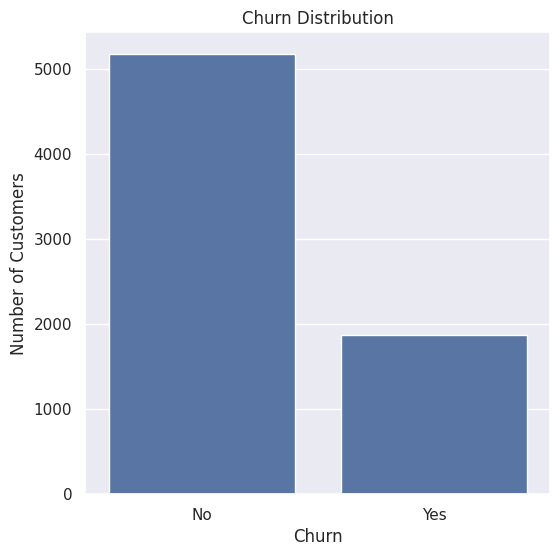

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
# ==========================================
# VISUALIZING TARGET VARIABLE DISTRIBUTION
# ==========================================

# Setting seaborn default theme for better visualization
sns.set()

# Creating the figure with specified size
plt.figure(figsize=(6, 6))

# Countplot is used to visualize the distribution
# of customers who churned and did not churn
sns.countplot(x=dataset['Churn'])

# Adding title and axis labels
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Displaying the plot
plt.show()

# Displaying the count of each class
# to check class balance/imbalance
dataset['Churn'].value_counts()

## 4.2 Plots for numerical data(histograms + BoxPlots)

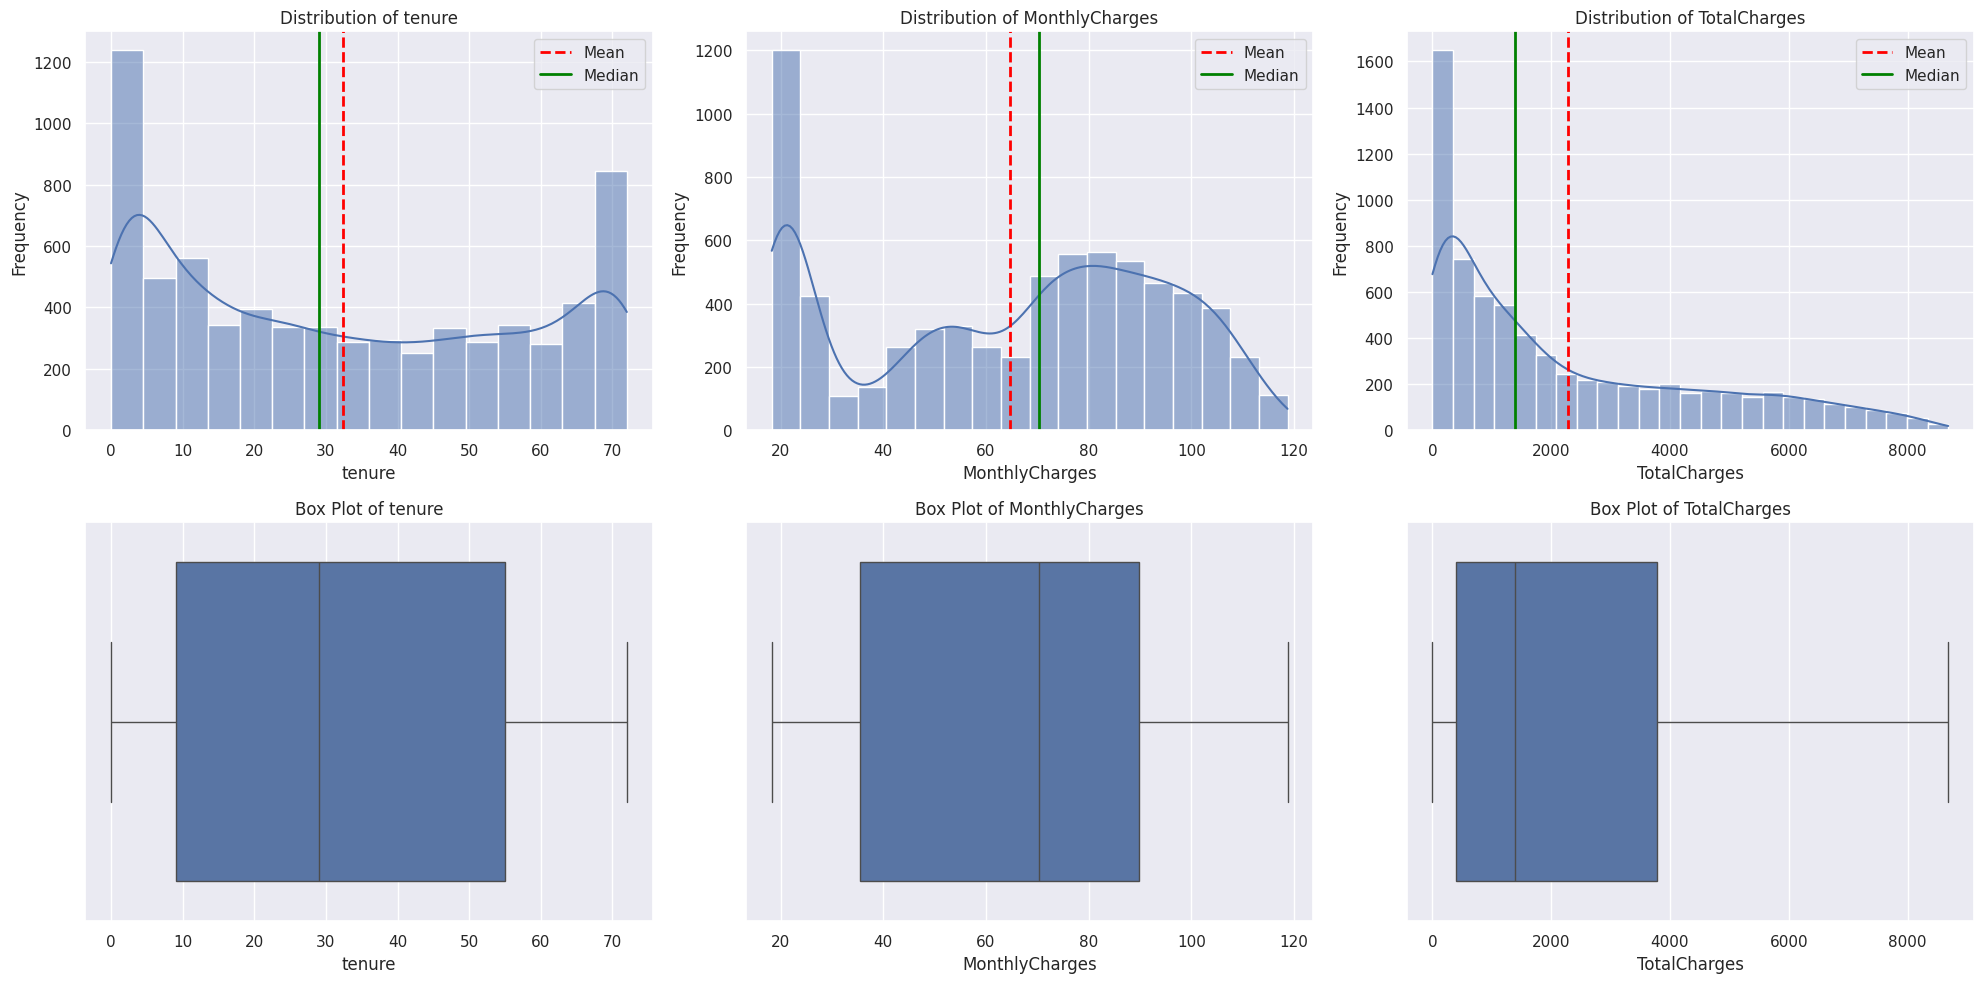

In [15]:
# ==========================================
# HISTOGRAM + BOXPLOT FOR NUMERICAL FEATURES
# ==========================================

# Creating figure
plt.figure(figsize=(20, 10))

# Looping through numerical features
for i, col in enumerate(numerical_feature_list, 1):

    # =========================
    # HISTOGRAM SUBPLOT
    # =========================

    # Top row plots
    plt.subplot(2, 3, i)

    # Histogram with KDE
    sns.histplot(dataset[col], kde=True)

    # Mean and Median
    col_mean = dataset[col].mean()
    col_median = dataset[col].median()

    plt.axvline(
        col_mean,
        color='red',
        linestyle='--',
        linewidth=2,
        label='Mean'
    )

    plt.axvline(
        col_median,
        color='green',
        linestyle='-',
        linewidth=2,
        label='Median'
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.legend()

    # =========================
    # BOXPLOT SUBPLOT
    # =========================

    # Bottom row plots
    plt.subplot(2, 3, i + 3)

    # Boxplot
    sns.boxplot(x=dataset[col])

    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)

# Adjusting spacing
plt.tight_layout()

# Displaying plots
plt.show()

## 4.3 Correlation HeatMap

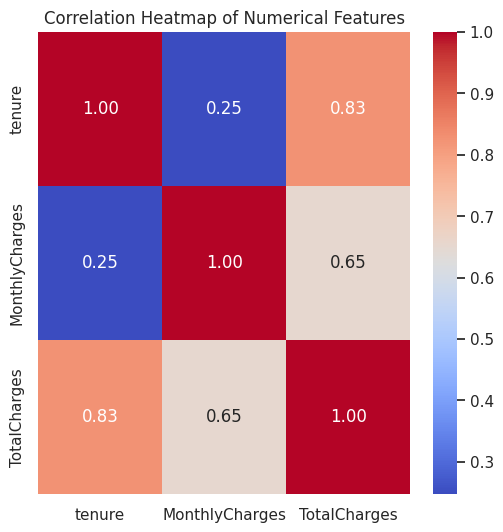

In [16]:
# ==========================================
# CORRELATION HEATMAP FOR NUMERICAL FEATURES
# ==========================================

# Creating figure for heatmap
plt.figure(figsize=(6, 6))

# Generating correlation matrix heatmap
# annot=True displays correlation values inside cells
# cmap='coolwarm' provides color gradient visualization
# fmt=".2f" displays values up to 2 decimal places

sns.heatmap(
    dataset[["tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

# Adding title
plt.title("Correlation Heatmap of Numerical Features")

# Displaying heatmap
plt.show()

## 4.4 Plots for Categorical data

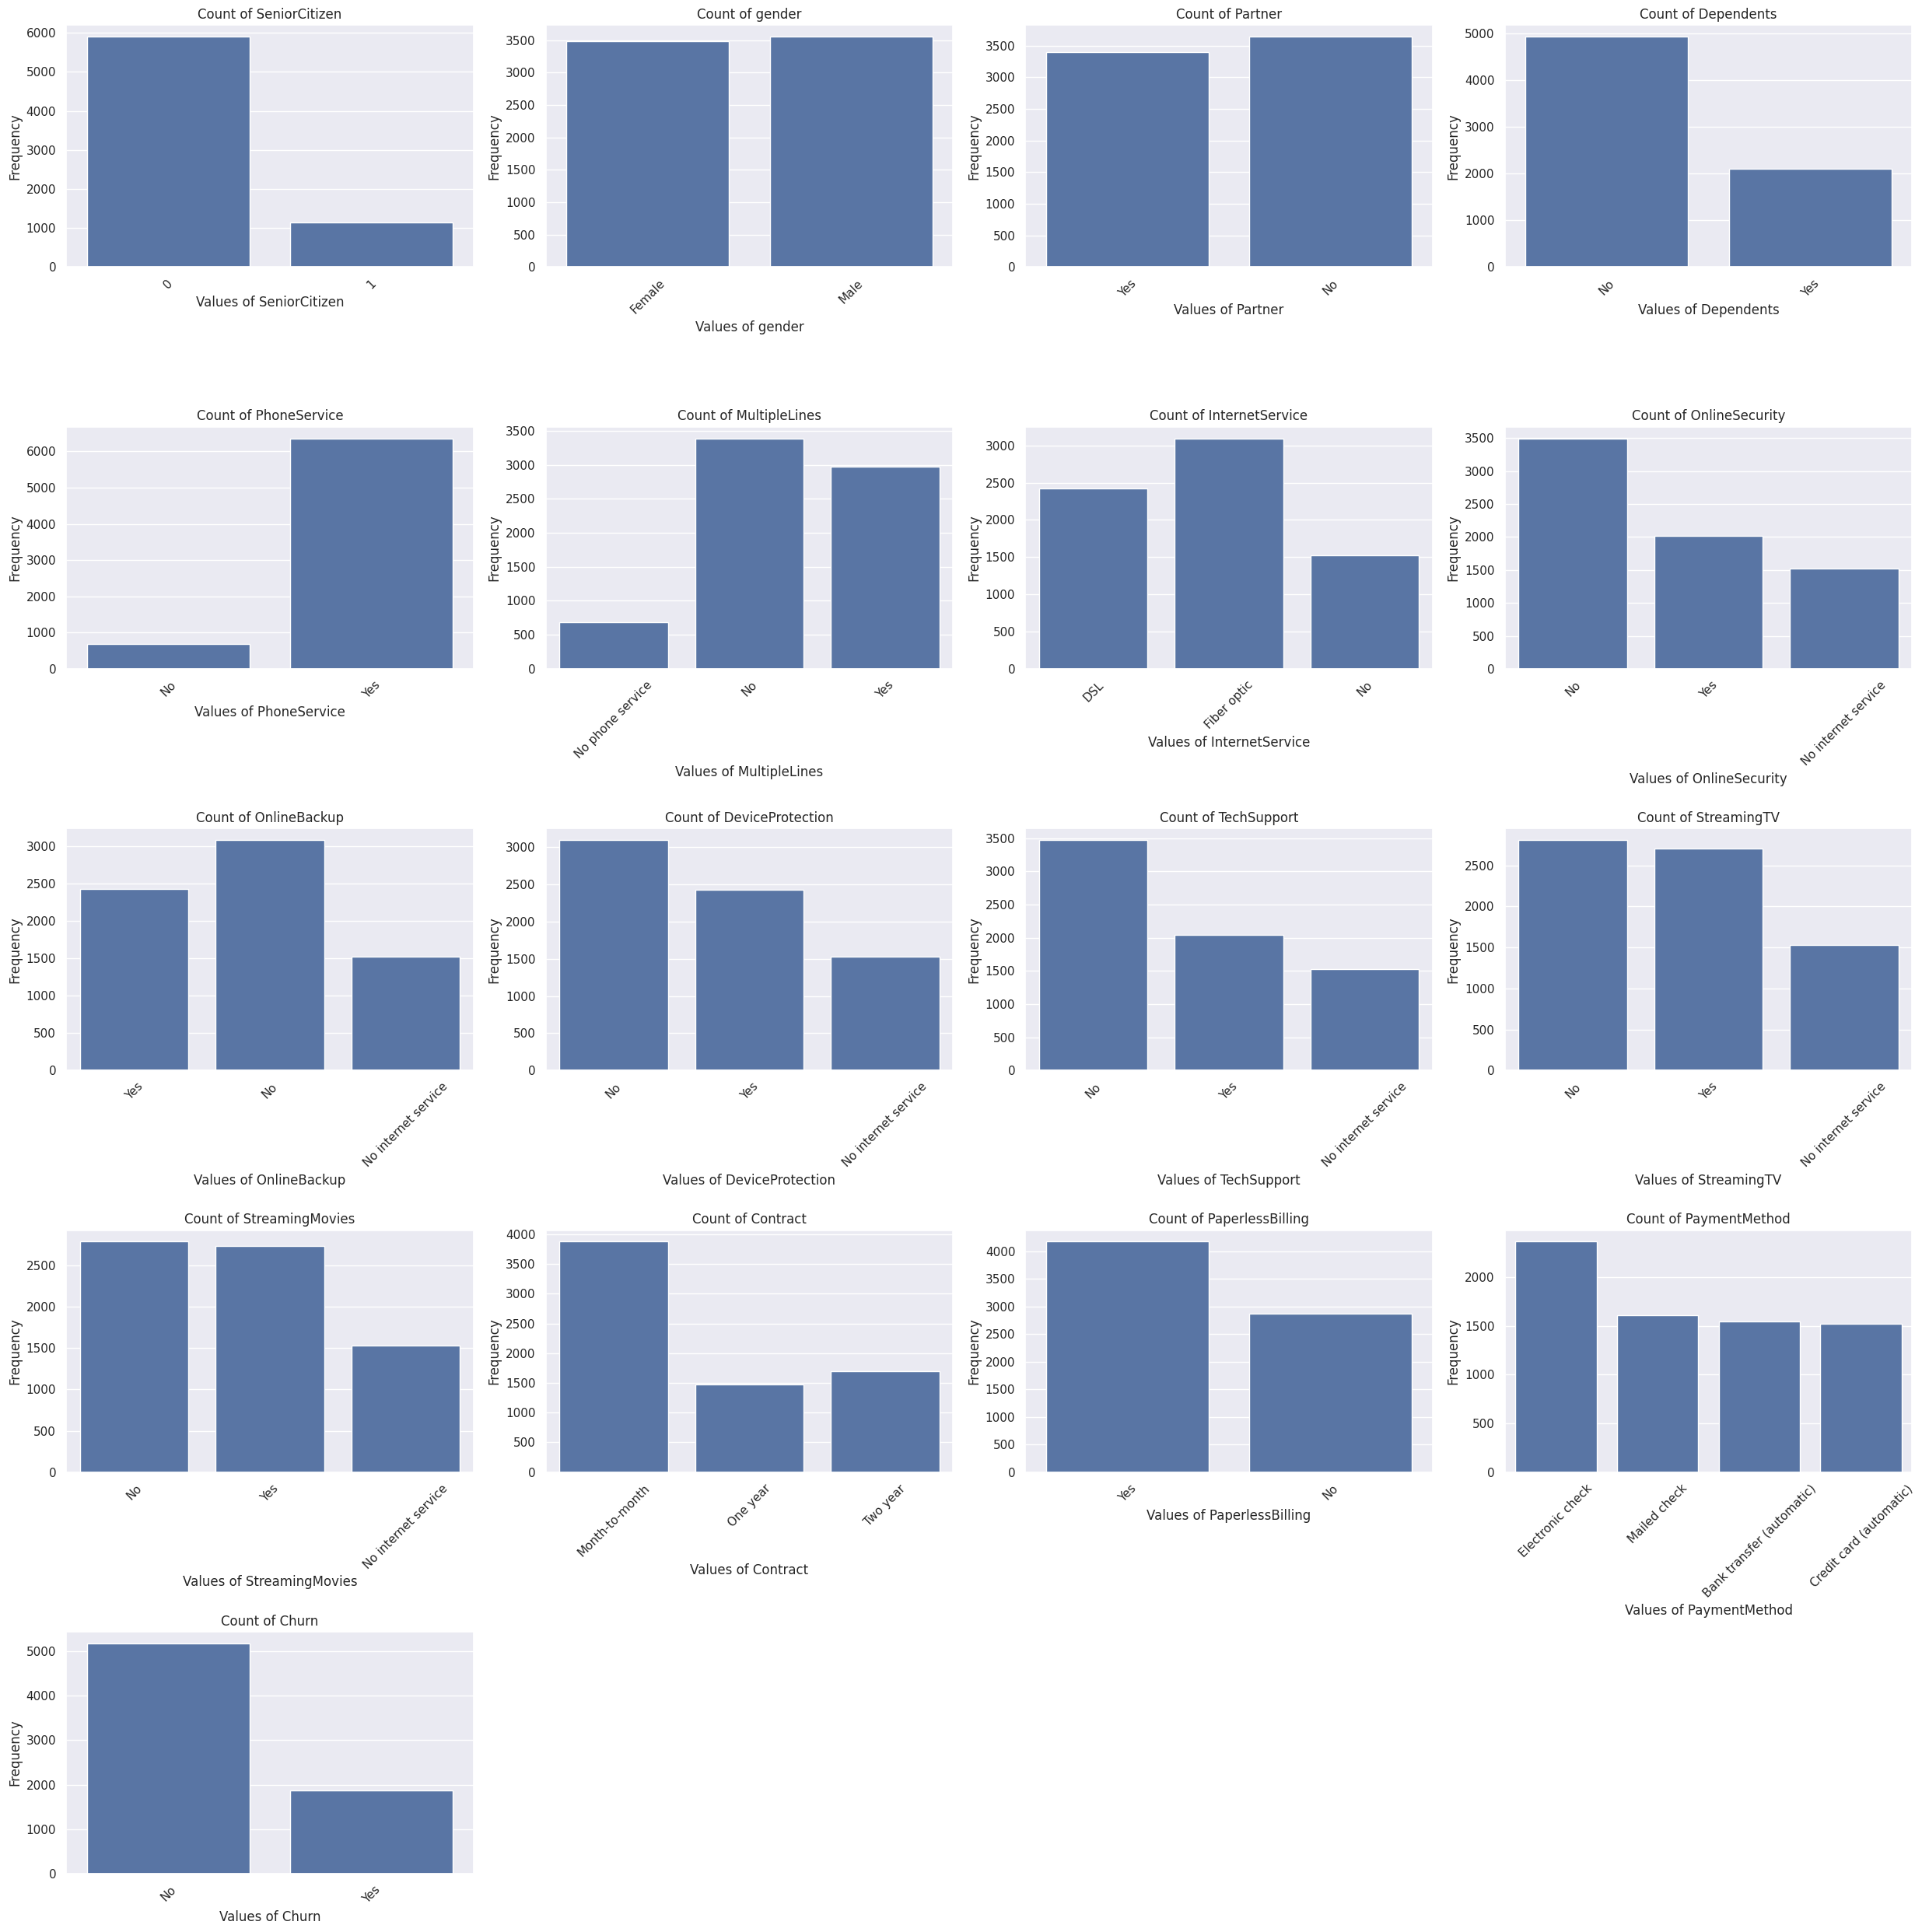

In [31]:
# ==========================================
# VISUALIZING CATEGORICAL FEATURES
# ==========================================

# Selecting all categorical columns from the dataset
categorical_feature_list = dataset.select_dtypes(
    include='object'
).columns.to_list()

# Adding 'SeniorCitizen' manually because
# it is numerical but represents categories
categorical_feature_list = ['SeniorCitizen'] + categorical_feature_list

# Creating figure for subplots
plt.figure(figsize=(25, 25))

# Looping through each categorical feature
for i, col in enumerate(categorical_feature_list, 1):

    # Creating subplot grid (4 rows, 5 columns)
    plt.subplot(5, 4, i)

    # Creating countplot
    sns.countplot(x=dataset[col])

    # Adding titles and labels
    plt.title(f"Count of {col}")
    plt.xlabel(f"Values of {col}")
    plt.ylabel("Frequency")

    # Rotating x-axis labels for better readability
    plt.xticks(rotation=45)

# Adjusting spacing between plots
plt.tight_layout()

# Displaying all plots
plt.show()

## 5. LabelEncoding of categorical data

In [ ]:
# ==========================================
# ENCODING TARGET VARIABLE
# ==========================================

# Converting 'Yes' and 'No' values in the
# target column 'Churn' into numerical values

dataset['Churn'] = dataset['Churn'].replace({
    "Yes": 1,
    "No": 0
})

# ==========================================
# LABEL ENCODING CATEGORICAL FEATURES
# ==========================================

# Dictionary to store encoders for each column
encoders = {}

#Removing the Churn column after transforming it
categorical_feature_list.remove('Churn')

# Looping through categorical columns
for col in categorical_feature_list:

    # Creating LabelEncoder object
    le = LabelEncoder()

    # Encoding categorical values into numbers
    dataset[col] = le.fit_transform(dataset[col])

    # Saving encoder for future use
    encoders[col] = le

# ==========================================
# SAVING ENCODERS USING PICKLE
# ==========================================

# Saving all encoders into a pickle file
# for later use during prediction/deployment

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Categorical features encoded successfully!")


In [34]:
dataset.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## 6. Train and testing data

In [35]:
# ==========================================
# SPLITTING DATA INTO FEATURES AND TARGET
# ==========================================

# Separating input features (X)
# by removing the target column 'Churn'
x = dataset.drop(columns=['Churn'], axis=1)

# Storing target variable (Y)
y = dataset['Churn']

# ==========================================
# TRAIN-TEST SPLIT
# ==========================================

# Splitting the dataset into training and testing sets
# test_size=0.2 means:
# - 80% data for training
# - 20% data for testing

# random_state ensures reproducibility
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=123
)

# ==========================================
# DISPLAYING DATA SHAPES
# ==========================================

# Printing shapes of training and testing data
print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("Successfully split the training and testing data.")

(1409, 19) (5634, 19)
(1409,) (5634,)
Successfully splitted the training and testing data.


In [36]:
# ==========================================
# CHECKING CLASS DISTRIBUTION IN TARGET VARIABLE
# ==========================================

# Displaying the count of each class
# in the training target variable

y_train.value_counts()

# Observation:
# The dataset contains class imbalance,
# where one class has significantly more
# samples than the other class.

# This imbalance can affect model performance
# because the model may become biased toward
# the majority class.

Churn
0    4159
1    1475
Name: count, dtype: int64

## 7. Smote(Synthetic Minority Oversampling Technique)

In [37]:
smote = SMOTE(random_state=123)

x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

y_train_smote.value_counts()


Churn
1    4159
0    4159
Name: count, dtype: int64

## 8. Model selection and training

In [39]:
# ==========================================
# INITIALIZING MACHINE LEARNING MODELS
# ==========================================

# Creating a dictionary to store multiple
# machine learning models for comparison

models = {

    # Random Forest Classifier
    "Random_Forest": RandomForestClassifier(
        random_state=12
    ),

    # Decision Tree Classifier
    "Decision_Tree": DecisionTreeClassifier(
        random_state=12
    ),

    # XGBoost Classifier
    "XGB": XGBClassifier(
        random_state=12,
        eval_metric='logloss'
    )
}

print("Models are selected successfully!")

Models are selected successfully!


In [45]:
# ==========================================
# PERFORMING CROSS VALIDATION
# ==========================================

# Dictionary to store cross-validation scores
cv_scores = {}

# Looping through each machine learning model
for model_name, model in models.items():

    # Displaying current model being trained
    print(f"Training the {model_name} model with default parameters.")

    # Performing 5-Fold Cross Validation
    # scoring='accuracy' evaluates model accuracy
    scores = cross_val_score(
        model,
        x_train_smote,
        y_train_smote,
        cv=5,
        scoring="accuracy"
    )

    # Storing scores in dictionary
    cv_scores[model_name] = scores

    # Displaying mean cross-validation accuracy
    print(
        f"{model_name} Mean Cross Validation Accuracy: "
        f"{np.mean(scores):.2f}"
    )

    # Displaying separator line
    print("_" * 50)

Training the Random_Forest model with default parameters.
Random_Forest Mean Cross Validation Accuracy: 0.84
__________________________________________________
Training the Decision_Tree model with default parameters.
Decision_Tree Mean Cross Validation Accuracy: 0.79
__________________________________________________
Training the XGB model with default parameters.
XGB Mean Cross Validation Accuracy: 0.84
__________________________________________________


## 9. HyperParameter Tuning

In [49]:
# ==========================================
# HYPERPARAMETER TUNING USING GRIDSEARCHCV
# ==========================================

from sklearn.model_selection import GridSearchCV

# Creating Random Forest model
rf_model = RandomForestClassifier(
    random_state=12
)

# Defining hyperparameter grid
param_grid_rf = {

    # Number of trees in the forest
    "n_estimators": [100, 200],

    # Maximum depth of each tree
    "max_depth": [10, 20, None],

    # Minimum samples required to split a node
    "min_samples_split": [2, 5],

    # Minimum samples required at leaf node
    "min_samples_leaf": [1, 2],

    # Whether bootstrap sampling is used
    "bootstrap": [True, False]
}

# ==========================================
# CREATING GRID SEARCH OBJECT
# ==========================================

grid_search_rf = GridSearchCV(

    estimator=rf_model,

    # Hyperparameter combinations to test
    param_grid=param_grid_rf,

    # 5-Fold Cross Validation
    cv=5,

    # Evaluation metric
    scoring='accuracy',

    # Use all CPU cores
    n_jobs=-1,

    # Display training progress
    verbose=2
)

# ==========================================
# TRAINING THE MODEL
# ==========================================

print("Performing GridSearchCV for Random Forest...")

grid_search_rf.fit(
    x_train_smote,
    y_train_smote
)

print("Hyperparameter tuning completed!")

# ==========================================
# DISPLAYING BEST PARAMETERS
# ==========================================

print("\nBest Parameters:")
print(grid_search_rf.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search_rf.best_score_)

Performing GridSearchCV for Random Forest...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Hyperparameter tuning completed!

Best Parameters:
{'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Score:
0.8428835746334243


## 10. Evaluating the Model

Accuracy Score:
0.7799858055358411

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1015
           1       0.61      0.60      0.61       394

    accuracy                           0.78      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.78      0.78      0.78      1409


Confusion Matrix:
[[861 154]
 [156 238]]


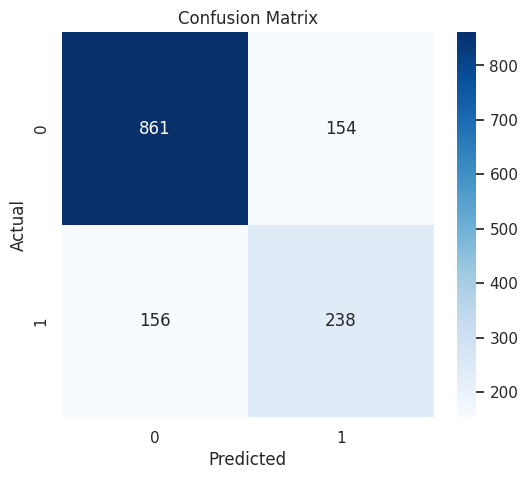

[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.5s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   2.3s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   2.2s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   2.3s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_s

In [52]:
# Getting the best model
best_rf_model = grid_search_rf.best_estimator_

# Making predictions
testing_prediction = best_rf_model.predict(x_test)

print("Accuracy Score:")
print(accuracy_score(y_test, testing_prediction))

print("\nClassification Report:")
print(classification_report(y_test, testing_prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, testing_prediction))

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, testing_prediction),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ✅ Why the Model Is Working Properly

---

## 📌 1. Accuracy Is Reasonable

The model achieved an overall accuracy of:

```python
Accuracy ≈ 78%
```

This means:

- Out of **1409 customers**
- The model correctly predicted approximately **78%** of them.

This represents a **solid baseline performance** for a customer churn prediction problem.

---

## 📌 2. The Model Successfully Learns Both Classes

One major issue in churn prediction is that models often become biased toward the majority class and fail to identify churn customers properly.

However, this model successfully predicts both:

- ✅ Non-Churn Customers
- ✅ Churn Customers

### Confusion Matrix

```python
[[861 154]
 [156 238]]
```

### Interpretation

| Prediction Result | Count |
|---|---|
| Correctly Predicted Non-Churn Customers | 861 |
| Incorrectly Predicted Non-Churn Customers | 154 |
| Missed Churn Customers | 156 |
| Correctly Predicted Churn Customers | 238 |

This shows that the model is genuinely learning meaningful churn behavior patterns rather than simply predicting the majority class.

---

## 📌 3. Recall for Churn Customers Is Acceptable

### Churn Recall Score

```python
Recall ≈ 60%
```

This means:

- The model correctly identifies approximately **60% of actual churn customers**.

In customer churn prediction:

- Recall is extremely important because:
  - Missing churn customers may lead to customer loss
  - Customer churn directly impacts business revenue

A recall score of **60%** is a good starting point for an initial Random Forest implementation.

---

## 📌 4. No Severe Overfitting Observed

The model’s:

- Cross-validation scores
- Test accuracy

are reasonably aligned.

This indicates that:

- ✅ The model generalizes well on unseen data
- ✅ The model is not heavily memorizing training samples
- ✅ The training pipeline is stable

---

# 🎯 Final Conclusion

The Random Forest model is functioning properly and demonstrates strong baseline performance for churn prediction.

### Key Strengths

- Good overall accuracy
- Successfully predicts both classes
- Reasonable churn detection capability
- Stable generalization performance

### Possible Future Improvements

- Improve recall for churn customers
- Experiment with XGBoost
- Perform advanced feature engineering
- Optimize threshold tuning
- Use ensemble techniques

Overall, the machine learning pipeline is correctly implemented and produces meaningful predictive results.